In [1]:
import json
import pandas as pd

In [2]:
"""
    Task - 1: 
        : get the layer distributions as a box plot for both base and instruct where we see planning features vs. which layers we see all FTE features.
    Task - 2:
        : see which y_ms do we observe at large.
"""

import glob

cluster_json_base = glob.glob("../outputs/scale-exp/base/prompt_*/token_*/clusters.json")
cluster_json_instruct = glob.glob("../outputs/scale-exp/instruct/prompt_*/token_*/clusters.json")

def _get_stats(file):
    with open(file, "r") as f:
        data = json.load(f)
    updated_analysis_file = file.replace("scale-exp", "t-scale-exp-v2").replace("clusters.json", "updated_planning_analysis.json")
    with open(updated_analysis_file, "r") as f:
        analysis_data = json.load(f)
    generic_dist = {}
    plan_only_dist = {}
    for key, val in data.items():
        for feature in val:
            layer, head, tokens = feature
            if layer not in generic_dist:
                generic_dist[layer] = set()
            generic_dist[layer].add(head)                
            if analysis_data[key]["new_verdict"] == "Plan":
                if layer not in plan_only_dist:
                    plan_only_dist[layer] = set()
                plan_only_dist[layer].add(head)

    return generic_dist, plan_only_dist                

overall_base_generic_set = {}
overall_base_plan_only_set = {}
overall_instruct_generic_set = {}
overall_instruct_plan_only_set = {}

def _merge_dicts_of_sets(d1, d2):
    """Merge two dictionaries of sets, combining sets for overlapping keys."""
    return {key: d1.get(key, set()) | d2.get(key, set())
            for key in set(d1) | set(d2)}

# Merge base sets
for base_file in cluster_json_base:
    generic_base_set, plan_only_base_set = _get_stats(base_file)
    overall_base_generic_set = _merge_dicts_of_sets(overall_base_generic_set, generic_base_set)
    overall_base_plan_only_set = _merge_dicts_of_sets(overall_base_plan_only_set, plan_only_base_set)

# Merge instruct sets
for instruct_file in cluster_json_instruct:
    generic_instruct_set, plan_only_instruct_set = _get_stats(instruct_file)
    overall_instruct_generic_set = _merge_dicts_of_sets(overall_instruct_generic_set, generic_instruct_set)
    overall_instruct_plan_only_set = _merge_dicts_of_sets(overall_instruct_plan_only_set, plan_only_instruct_set)

In [3]:
len(list(overall_base_generic_set.keys())), list(overall_base_plan_only_set.keys())

(26,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25])

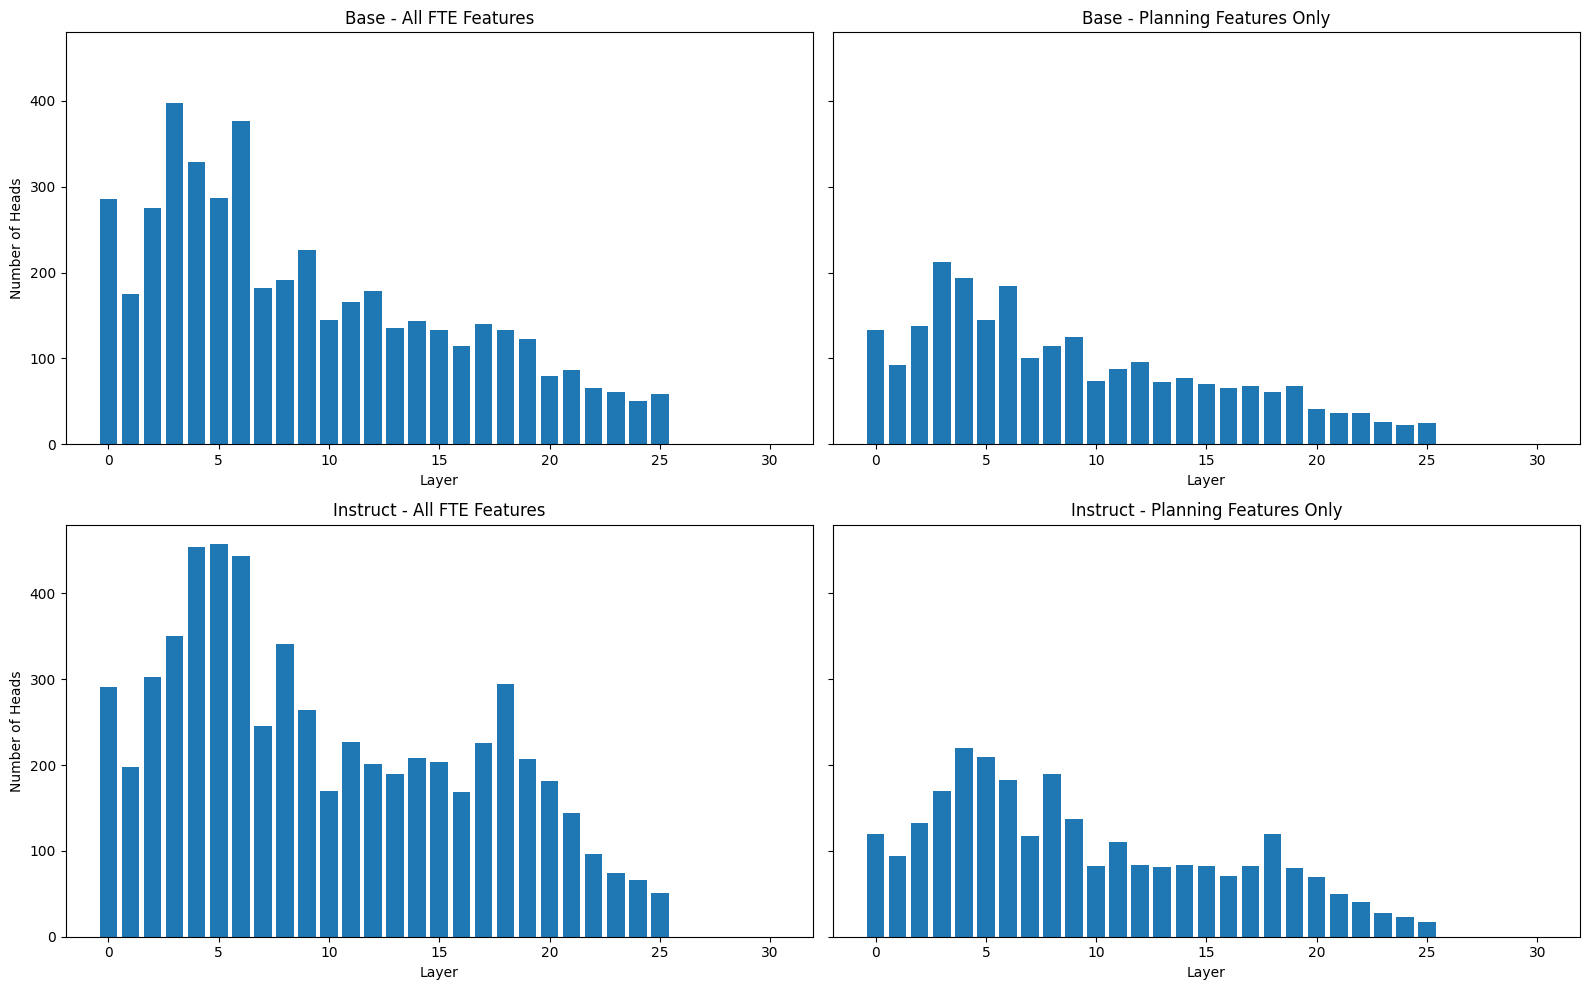

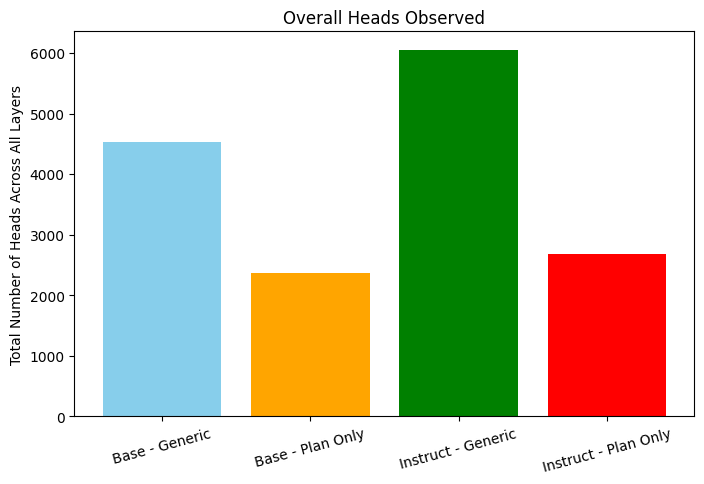

In [4]:
import matplotlib.pyplot as plt

def count_heads_per_layer(overall_dict, num_layers=31):
    """Return a list with the number of heads in each layer."""
    return [len(overall_dict.get(layer, set())) for layer in range(num_layers)]

num_layers = 31
layers = list(range(num_layers))

# Count heads per layer
base_generic_counts = count_heads_per_layer(overall_base_generic_set, num_layers)
base_plan_counts = count_heads_per_layer(overall_base_plan_only_set, num_layers)
instruct_generic_counts = count_heads_per_layer(overall_instruct_generic_set, num_layers)
instruct_plan_counts = count_heads_per_layer(overall_instruct_plan_only_set, num_layers)

# Task 1: Plot number of heads per layer (bar plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

axes[0, 0].bar(layers, base_generic_counts)
axes[0, 0].set_title("Base - All FTE Features")
axes[0, 0].set_xlabel("Layer")
axes[0, 0].set_ylabel("Number of Heads")

axes[0, 1].bar(layers, base_plan_counts)
axes[0, 1].set_title("Base - Planning Features Only")
axes[0, 1].set_xlabel("Layer")

axes[1, 0].bar(layers, instruct_generic_counts)
axes[1, 0].set_title("Instruct - All FTE Features")
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("Number of Heads")

axes[1, 1].bar(layers, instruct_plan_counts)
axes[1, 1].set_title("Instruct - Planning Features Only")
axes[1, 1].set_xlabel("Layer")

plt.tight_layout()
plt.show()

# Task 2: Overall number of heads (sum across layers)
overall_counts = {
    "Base - Generic": sum(base_generic_counts),
    "Base - Plan Only": sum(base_plan_counts),
    "Instruct - Generic": sum(instruct_generic_counts),
    "Instruct - Plan Only": sum(instruct_plan_counts)
}

plt.figure(figsize=(8,5))
plt.bar(overall_counts.keys(), overall_counts.values(), color=['skyblue','orange','green','red'])
plt.ylabel("Total Number of Heads Across All Layers")
plt.title("Overall Heads Observed")
plt.xticks(rotation=15)
plt.show()

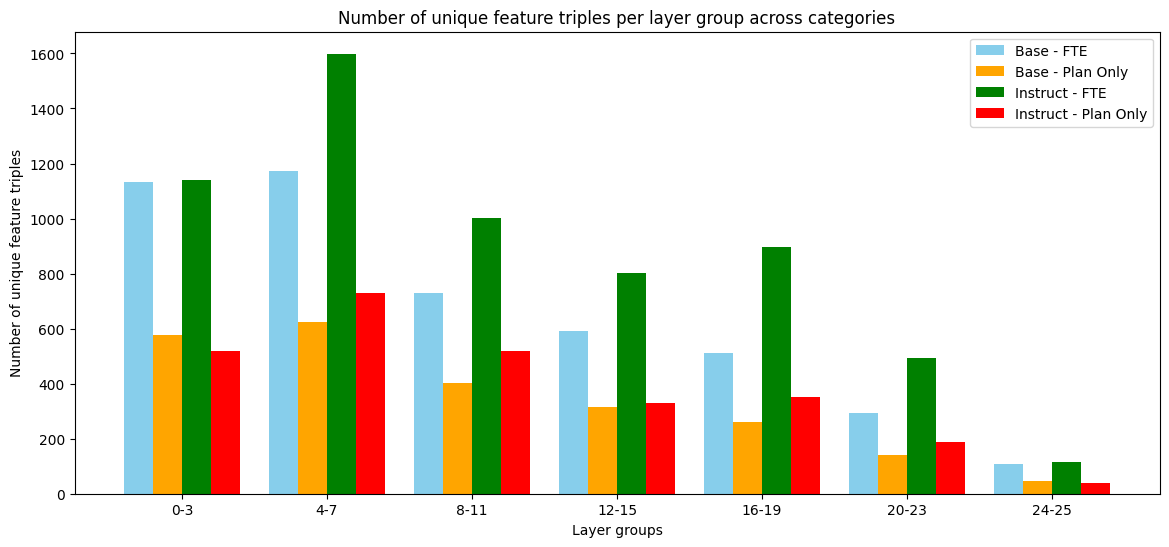

In [5]:
import matplotlib.pyplot as plt
import numpy as np

num_layers = 26
bin_size = 4  # Number of layers per bin
layers = np.arange(num_layers)

# Function to count heads per layer
def count_heads_per_layer(overall_dict, num_layers=num_layers):
    return [len(overall_dict.get(layer, set())) for layer in range(num_layers)]

# Counts per layer
base_generic_counts = count_heads_per_layer(overall_base_generic_set)
base_plan_counts = count_heads_per_layer(overall_base_plan_only_set)
instruct_generic_counts = count_heads_per_layer(overall_instruct_generic_set)
instruct_plan_counts = count_heads_per_layer(overall_instruct_plan_only_set)

# Function to bin layers
def bin_counts(counts, bin_size):
    binned = []
    for i in range(0, len(counts), bin_size):
        binned.append(sum(counts[i:i+bin_size]))
    return binned

binned_layers = [f"{i}-{min(i+bin_size-1, num_layers-1)}" for i in range(0, num_layers, bin_size)]
base_generic_binned = bin_counts(base_generic_counts, bin_size)
base_plan_binned = bin_counts(base_plan_counts, bin_size)
instruct_generic_binned = bin_counts(instruct_generic_counts, bin_size)
instruct_plan_binned = bin_counts(instruct_plan_counts, bin_size)

# Plotting grouped bar chart
x = np.arange(len(binned_layers))
width = 0.2

plt.figure(figsize=(14,6))
plt.bar(x - 1.5*width, base_generic_binned, width, label='Base - FTE', color='skyblue')
plt.bar(x - 0.5*width, base_plan_binned, width, label='Base - Plan Only', color='orange')
plt.bar(x + 0.5*width, instruct_generic_binned, width, label='Instruct - FTE', color='green')
plt.bar(x + 1.5*width, instruct_plan_binned, width, label='Instruct - Plan Only', color='red')

plt.xticks(x, binned_layers)
plt.xlabel("Layer groups")
plt.ylabel("Number of unique feature triples")
plt.title("Number of unique feature triples per layer group across categories")
plt.legend()
plt.show()

## now.
- get the feature tuples themselves with a counter on how many instances we observe planning in.
- get the graphs the distribution of frequency of usage of a particular feature tuple in planning.

## then, get.
- the distribution of 10 most planned for tokens.

In [6]:
cluster_json_base = glob.glob("../outputs/scale-exp/base/prompt_*/token_*/clusters.json")
cluster_json_instruct = glob.glob("../outputs/scale-exp/instruct/prompt_*/token_*/clusters.json")

def _get_stats(file):
    with open(file, "r") as f:
        data = json.load(f)
    updated_analysis_file = file.replace("scale-exp", "t-scale-exp-v2").replace("clusters.json", "updated_planning_analysis.json")
    with open(updated_analysis_file, "r") as f:
        analysis_data = json.load(f)
    generic_dist = {}
    plan_only_dist = {}
    for key, val in data.items():
        for feature in val:
            layer, head, tokens = feature
            if (layer, head) not in generic_dist:
                generic_dist[(layer, head)] = 0
            generic_dist[(layer, head)] += 1
            if analysis_data[key]["new_verdict"] == "Plan":
                if layer not in plan_only_dist:
                    plan_only_dist[(layer, head)] = 0
                plan_only_dist[(layer, head)] += 1

    return generic_dist, plan_only_dist                

overall_base_generic_set = {}
overall_base_plan_only_set = {}
overall_instruct_generic_set = {}
overall_instruct_plan_only_set = {}

from collections import Counter

def _merge_frequency_dicts(*dicts):
    """
    Merge multiple dictionaries of counts by summing values for overlapping keys.
    
    Args:
        *dicts: any number of dicts where values are numeric counts
    
    Returns:
        dict: merged dictionary with summed counts
    """
    total_counter = Counter()
    for d in dicts:
        total_counter.update(d)
    return dict(total_counter)

# Merge base sets
for base_file in cluster_json_base:
    generic_base_set, plan_only_base_set = _get_stats(base_file)
    overall_base_generic_set = _merge_frequency_dicts(overall_base_generic_set, generic_base_set)
    overall_base_plan_only_set = _merge_frequency_dicts(overall_base_plan_only_set, plan_only_base_set)

# Merge instruct sets
for instruct_file in cluster_json_instruct:
    generic_instruct_set, plan_only_instruct_set = _get_stats(instruct_file)
    overall_instruct_generic_set = _merge_frequency_dicts(overall_instruct_generic_set, generic_instruct_set)
    overall_instruct_plan_only_set = _merge_frequency_dicts(overall_instruct_plan_only_set, plan_only_instruct_set)

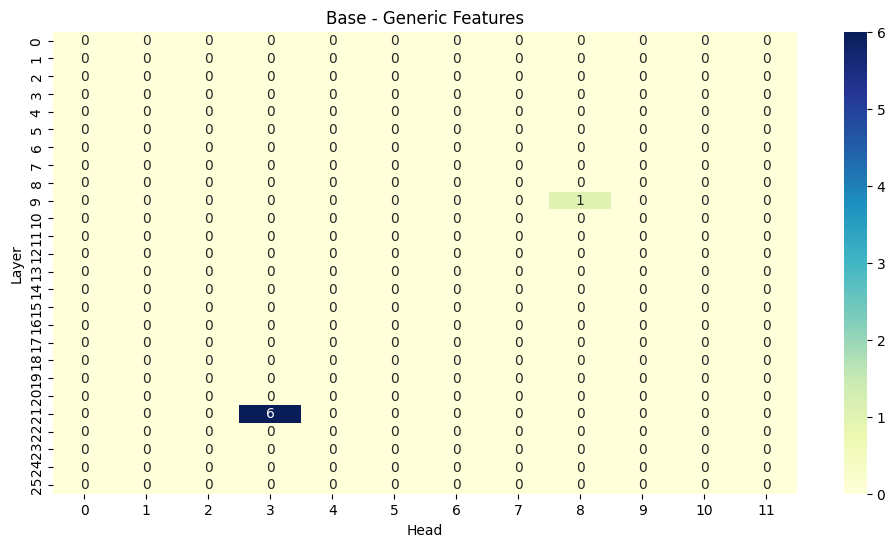

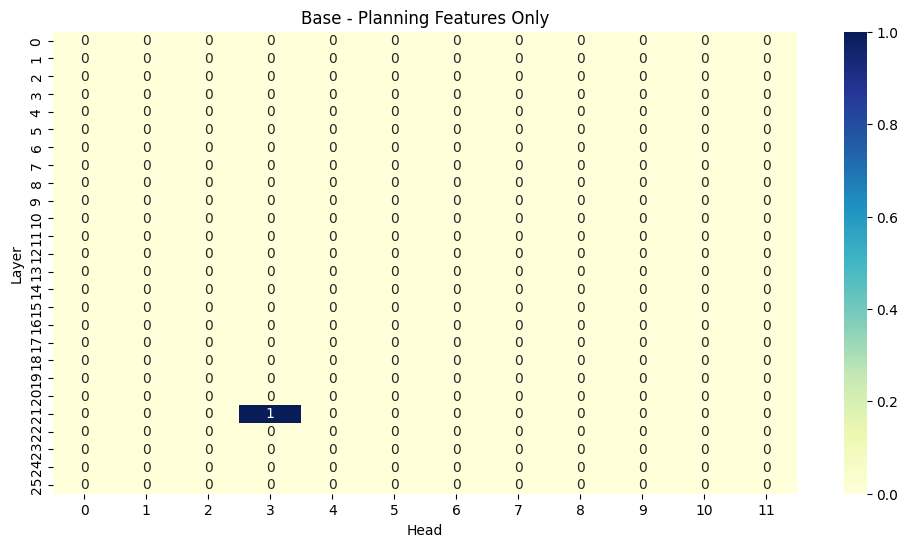

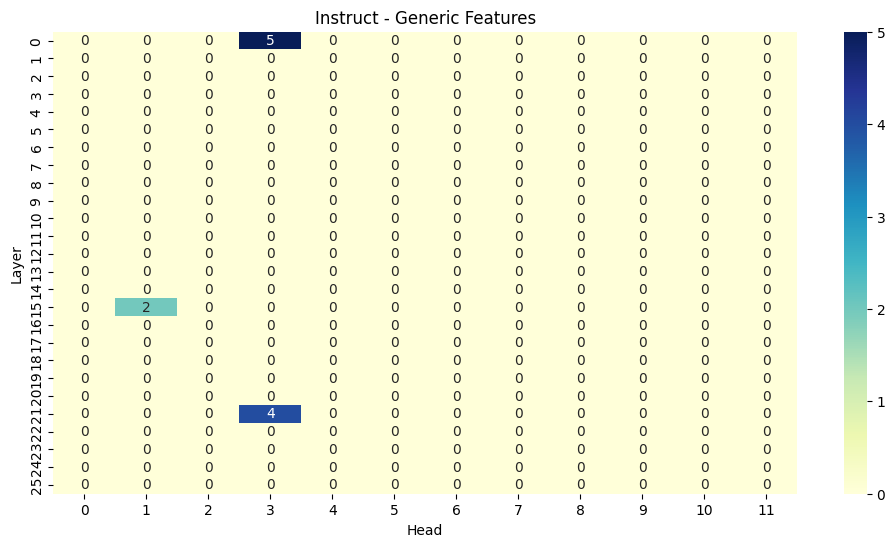

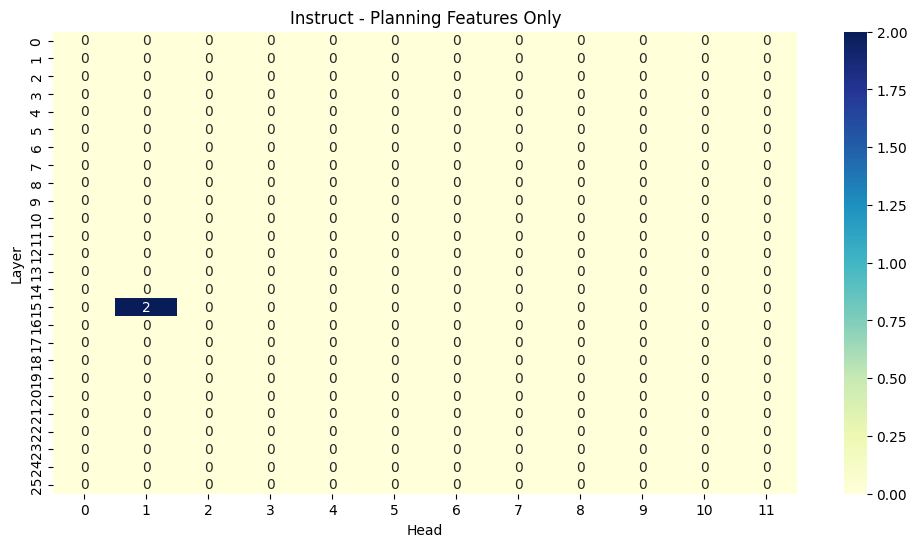

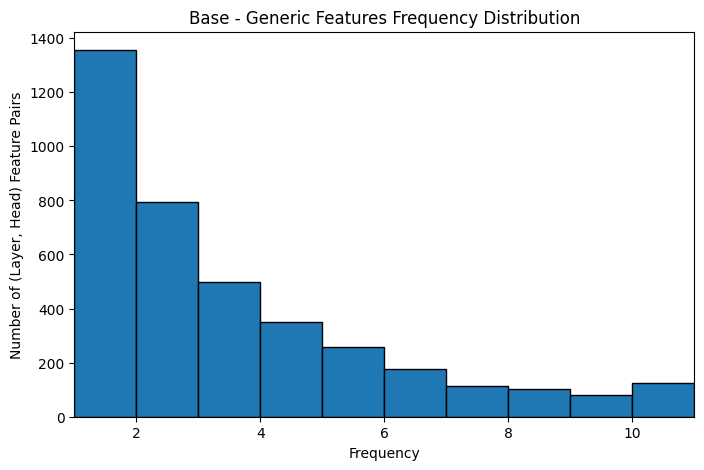

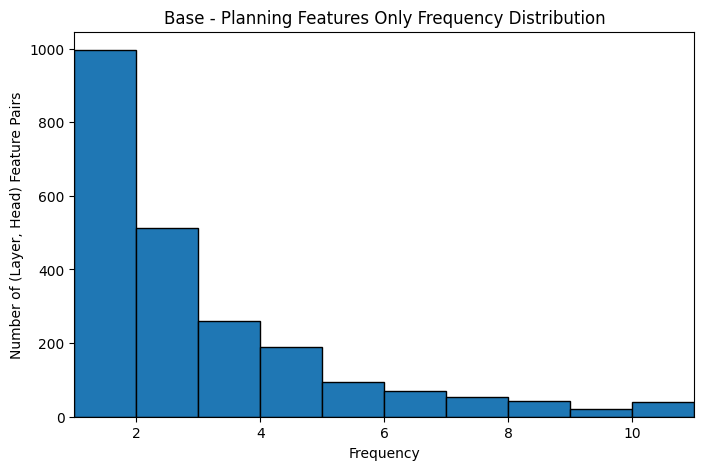

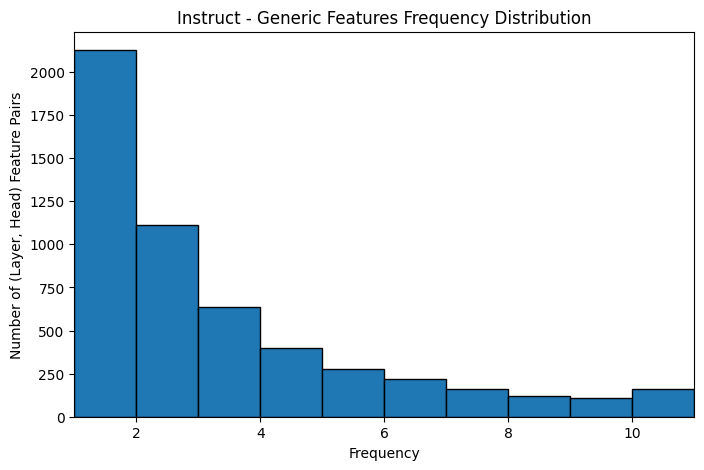

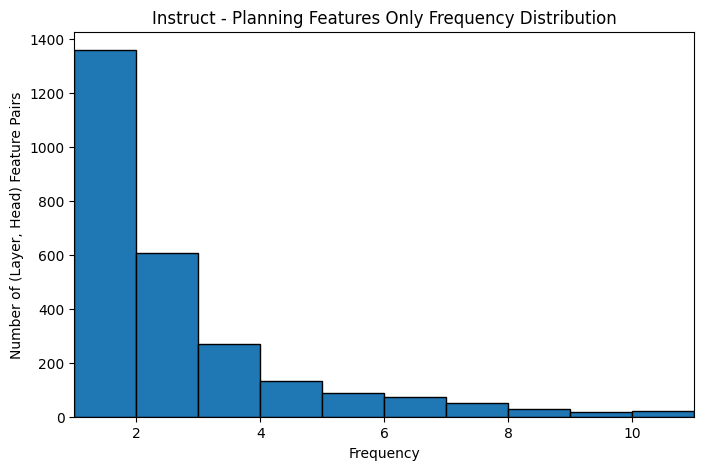

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_layers = 26
num_heads = 12  # adjust if your model has a different number of heads

all_dicts = [
    overall_base_generic_set,
    overall_base_plan_only_set,
    overall_instruct_generic_set,
    overall_instruct_plan_only_set
]

all_counts = [
    count
    for d in all_dicts
    for count in d.values()
]

HIST_MAX = max(all_counts)


# def plot_frequency_hist(instance_dict, title):
#     counts = list(instance_dict.values())
#     plt.figure(figsize=(8, 5))
#     plt.hist(
#         counts,
#         bins=20,
#         range=(0, HIST_MAX),
#         edgecolor='black'
#     )
#     plt.xlim(0, HIST_MAX)
#     plt.xlabel("Frequency")
#     plt.ylabel("Number of (Layer, Head) Feature Pairs")
#     plt.title(title)
#     plt.show()

def plot_frequency_hist(instance_dict, title):
    counts = list(instance_dict.values())

    plt.figure(figsize=(8, 5))
    plt.hist(
        counts,
        bins=10,
        range=(1, 11),
        edgecolor='black'
    )

    plt.xlim(1, 11)
    plt.xlabel("Frequency")
    plt.ylabel("Number of (Layer, Head) Feature Pairs")
    plt.title(title)
    plt.show()



def make_heatmap(instance_dict, title, num_layers=num_layers, num_heads=num_heads):
    """Convert frequency dict to a 2D array and plot heatmap."""
    matrix = np.zeros((num_layers, num_heads))
    for (layer, head), count in instance_dict.items():
        if layer < num_layers and head < num_heads:
            matrix[layer, head] = count
    plt.figure(figsize=(12,6))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.title(title)
    plt.show()

# Task 1: Heatmaps for each category
make_heatmap(overall_base_generic_set, "Base - Generic Features")
make_heatmap(overall_base_plan_only_set, "Base - Planning Features Only")
make_heatmap(overall_instruct_generic_set, "Instruct - Generic Features")
make_heatmap(overall_instruct_plan_only_set, "Instruct - Planning Features Only")

# Task 2: Optional histograms of frequencies
# def plot_frequency_hist(instance_dict, title):
#     counts = list(instance_dict.values())
#     plt.figure(figsize=(8,5))
#     plt.hist(counts, bins=20, color='skyblue', edgecolor='black')
#     plt.xlabel("Frequency")
#     plt.ylabel("Number of (Layer, Idx) Feature Pairs")
#     plt.title(title)
#     plt.show()

plot_frequency_hist(overall_base_generic_set, "Base - Generic Features Frequency Distribution")
plot_frequency_hist(overall_base_plan_only_set, "Base - Planning Features Only Frequency Distribution")
plot_frequency_hist(overall_instruct_generic_set, "Instruct - Generic Features Frequency Distribution")
plot_frequency_hist(overall_instruct_plan_only_set, "Instruct - Planning Features Only Frequency Distribution")

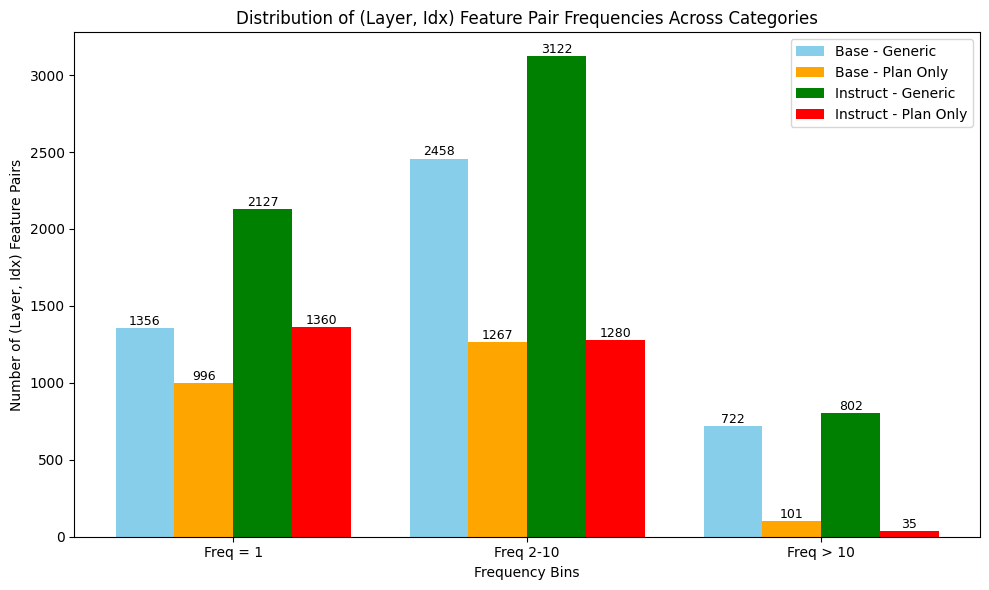

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def bin_feature_frequencies(instance_dict):
    """
    Bin (Layer, Idx) feature pair frequencies into:
    - 1
    - 2-10
    - >10 (log scale)
    Returns counts for each bin.
    """
    counts = np.array(list(instance_dict.values()))
    
    bin1 = np.sum(counts == 1)
    bin2 = np.sum((counts >= 2) & (counts <= 10))
    bin3 = np.sum(counts > 10)
    
    return [bin1, bin2, bin3]

def elegant_feature_plot(dicts, labels, colors):
    """
    Plot an elegant grouped bar chart of feature pair frequencies.
    """
    n_bins = 3
    x = np.arange(n_bins)
    width = 0.2
    
    plt.figure(figsize=(10,6))
    
    # Plot bars for each category
    for i, (d, label, color) in enumerate(zip(dicts, labels, colors)):
        counts = bin_feature_frequencies(d)
        plt.bar(x + i*width, counts, width=width, label=label, color=color)
        # Annotate bars
        for xi, c in zip(x + i*width, counts):
            plt.text(xi, c + 0.5, str(c), ha='center', va='bottom', fontsize=9)
    
    plt.xticks(x + width*(len(dicts)-1)/2, ['Freq = 1', 'Freq 2-10', 'Freq > 10'])
    plt.ylabel("Number of (Layer, Idx) Feature Pairs")
    plt.xlabel("Frequency Bins")
    plt.title("Distribution of (Layer, Idx) Feature Pair Frequencies Across Categories")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Categories
dicts = [overall_base_generic_set, overall_base_plan_only_set,
         overall_instruct_generic_set, overall_instruct_plan_only_set]
labels = ["Base - Generic", "Base - Plan Only", "Instruct - Generic", "Instruct - Plan Only"]
colors = ['skyblue','orange','green','red']

elegant_feature_plot(dicts, labels, colors)


### now:
-  get the venn diagram differences between y_m and y_m frequencies between base and instruct.

In [9]:
planning_analysis_json_base = glob.glob("../outputs/t-scale-exp-v2/base/prompt_*/token_*/updated_planning_analysis.json")
planning_analysis_json_instruct = glob.glob("../outputs/t-scale-exp-v2/instruct/prompt_*/token_*/updated_planning_analysis.json")

def _get_ym_stats(file):
    with open(file, "r") as f:
        data = json.load(f)
    all_keys_set = set()
    plan_keys_set = set()
    for key, value in data.items():
        if value["new_verdict"] == "Plan":
            plan_keys_set.add(key)
        all_keys_set.add(key)

    return plan_keys_set, all_keys_set

from collections import Counter

base_plan_instance_dict = {}
base_all_instance_dict = {}
instruct_plan_instance_dict = {}
instruct_all_instance_dict = {}

def _add_to_dict(main_dict, x, p_file):
    if x not in main_dict:
            main_dict[x] = set()
    prompt_idx = p_file.split("prompt_")[1].split("/")[0]
    main_dict[x].add(prompt_idx)

for file in planning_analysis_json_base:
    plan_keys_set, all_keys_set = _get_ym_stats(file)
    for x in plan_keys_set:
        _add_to_dict(base_plan_instance_dict, x, file)    
    for x in all_keys_set:
        _add_to_dict(base_all_instance_dict, x, file)

for file in planning_analysis_json_instruct:
    plan_keys_set, all_keys_set = _get_ym_stats(file)
    for x in plan_keys_set:
        _add_to_dict(instruct_plan_instance_dict, x, file)
    for x in all_keys_set:
        _add_to_dict(instruct_all_instance_dict, x, file)

base_plan_freq_dict = {x: len(base_plan_instance_dict[x]) for x in base_plan_instance_dict}
base_all_freq_dict = {x: len(base_all_instance_dict[x]) for x in base_all_instance_dict}
instruct_plan_freq_dict = {x: len(instruct_plan_instance_dict[x]) for x in instruct_plan_instance_dict}
instruct_all_freq_dict = {x: len(instruct_all_instance_dict[x]) for x in instruct_all_instance_dict}

In [10]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

def plot_key_venn(freq1, freq2, labels=('Dict1', 'Dict2'), title = "Default title"):
    """
    Plots a Venn diagram showing which keys exist in two frequency dictionaries.

    Args:
        freq1 (dict): First frequency dictionary.
        freq2 (dict): Second frequency dictionary.
        labels (tuple): Labels for the two sets (default: ('Dict1', 'Dict2')).
    """
    set1, set2 = set(freq1.keys()), set(freq2.keys())
    venn2([set1, set2], set_labels=labels)
    plt.title(title)
    plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_freq_heatmap(freq1, freq2, labels=('Dict1', 'Dict2'), cmap='Blues', x_label = "Keys", y_label = "Dictionaries", title = "Frequency Heatmap"):
    """
    Plots a heatmap comparing frequencies of two dictionaries.

    Args:
        freq1 (dict): First frequency dictionary.
        freq2 (dict): Second frequency dictionary.
        labels (tuple): Labels for the two dictionaries (default: ('Dict1', 'Dict2')).
        cmap (str): Seaborn color map for the heatmap.
    """
    # Get union of all keys
    all_keys = sorted(set(freq1) | set(freq2))
    
    # Create DataFrame with missing keys filled as 0
    data = pd.DataFrame({
        labels[0]: [freq1.get(k, 0) for k in all_keys],
        labels[1]: [freq2.get(k, 0) for k in all_keys]
    }, index=all_keys)
    
    # Plot heatmap
    plt.figure(figsize=(max(6, len(all_keys) * 0.5), 6))
    sns.heatmap(data, annot=True, cmap=cmap, fmt='g')
    plt.title(title)
    plt.ylabel(x_label)
    plt.xlabel(y_label)
    plt.show()

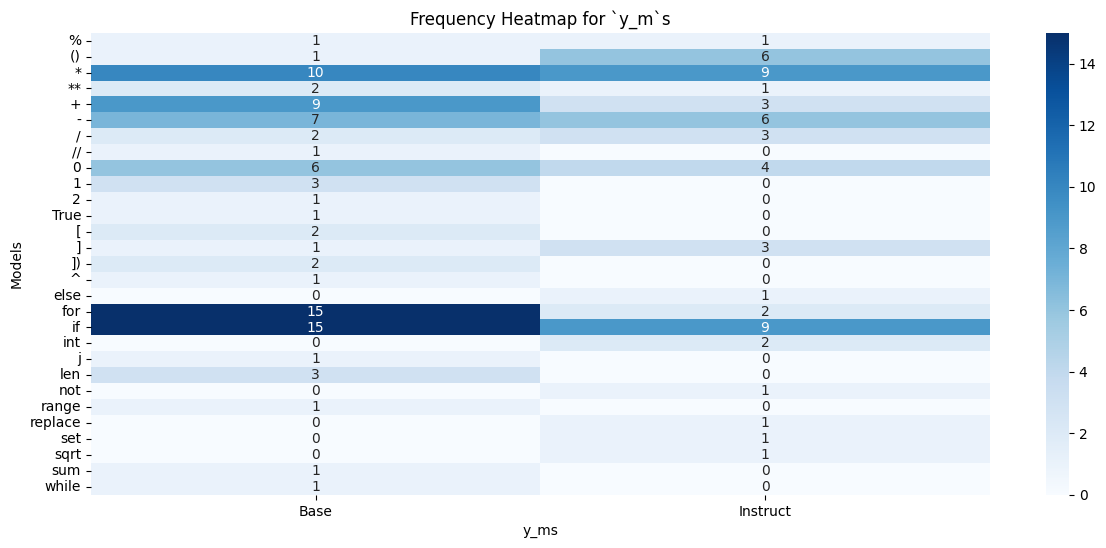

In [12]:
plot_freq_heatmap(
    base_plan_freq_dict, 
    instruct_plan_freq_dict, 
    labels = ("Base", "Instruct"), 
    title = "Frequency Heatmap for `y_m`s",
    x_label = "Models",
    y_label = "y_ms"
)

In [13]:
def plot_freq_bars(
    freq1, 
    freq2, 
    labels=('Dict1', 'Dict2'), 
    title='Frequency Comparison (with missing keys as 0)',
    xlabel='Keys',
    ylabel='Frequency',
    legend_loc='best',
    bar_width=0.35,
    figsize=(8, 6)
):
    """
    Plots a side-by-side bar chart comparing frequencies of two dictionaries.

    Args:
        freq1 (dict): First frequency dictionary.
        freq2 (dict): Second frequency dictionary.
        labels (tuple): Labels for the two dictionaries (default: ('Dict1', 'Dict2')).
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        legend_loc (str): Location of the legend (default: 'best').
        bar_width (float): Width of each bar (default: 0.35).
        figsize (tuple): Figure size (default: (8,6)).
    """
    all_keys = sorted(set(freq1) | set(freq2))  # union of keys
    vals1 = [freq1.get(k, 0) for k in all_keys]
    vals2 = [freq2.get(k, 0) for k in all_keys]

    x = np.arange(len(all_keys))

    plt.figure(figsize=figsize)
    plt.bar(x - bar_width/2, vals1, bar_width, label=labels[0])
    plt.bar(x + bar_width/2, vals2, bar_width, label=labels[1])
    plt.xticks(x, all_keys)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()

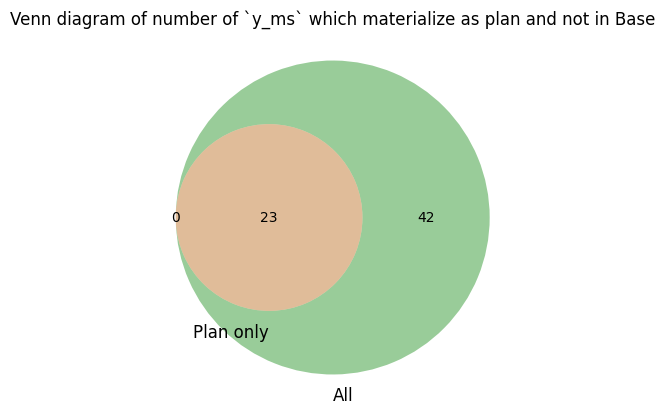

In [14]:
plot_key_venn(base_plan_freq_dict, base_all_freq_dict, ("Plan only", "All"), "Venn diagram of number of `y_ms` which materialize as plan and not in Base")

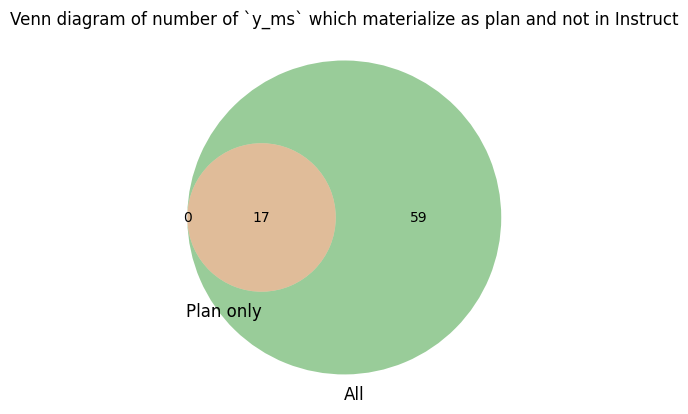

In [15]:
plot_key_venn(instruct_plan_freq_dict, instruct_all_freq_dict, ("Plan only", "All"), "Venn diagram of number of `y_ms` which materialize as plan and not in Instruct")

### now.
-- do a simple case study, try to understand the `()` plans in instruct and `for` plans in base.
-- the table will be like:
    Columns -> domain of the problem, where and why was it triggered, what happens when it is suppressed.
-- then, we have a categorization of domains and what happens when it is suppressed.

In [16]:
## get 10 cases for each thing, at max we should have 30 tasks I guess.
imp_base_yms = ["for", "1", "len"]
imp_instruct_yms = ["()", "]", "int"]
imp_common_yms = ["-", "/", "*"]

base_cases = []
instruct_cases = []
common_cases = []

## get the prompts and everything from instance_dict only.
for key, item in base_plan_instance_dict.items():
    if key in imp_base_yms:
        for v in item:
            base_cases.append((key, v))

for key, item in instruct_plan_instance_dict.items():
    if key in imp_instruct_yms:
        for v in item:
            instruct_cases.append((key, v))

for y_m in imp_common_yms:
    if y_m in base_plan_instance_dict and y_m in instruct_plan_instance_dict:
        sa = base_plan_instance_dict[y_m]
        sb = instruct_plan_instance_dict[y_m]
        sc = sa.intersection(sb)
        for x in sc:
            common_cases.append((y_m, x))

len(base_cases), len(instruct_cases), len(common_cases)

(21, 11, 12)

In [17]:
import random

def _sample_cases(cases):
    return random.sample(cases, 10)

sampled_base_cases = _sample_cases(base_cases)
sampled_instruct_cases = _sample_cases(instruct_cases)
sampled_common_cases = _sample_cases(common_cases)

In [18]:
print(sampled_base_cases)

[('for', '4'), ('len', '4'), ('for', '53'), ('for', '5'), ('for', '35'), ('for', '52'), ('for', '57'), ('for', '17'), ('for', '41'), ('1', '19')]


In [19]:
print(sampled_instruct_cases)

[('()', '18'), (']', '3'), ('()', '29'), (']', '76'), ('()', '31'), ('()', '22'), ('int', '0'), ('()', '75'), (']', '50'), ('int', '2')]


In [20]:
print(sampled_common_cases)

[('*', '58'), ('*', '21'), ('-', '2'), ('/', '14'), ('*', '32'), ('*', '6'), ('*', '50'), ('*', '2'), ('-', '4'), ('*', '51')]


### check out the analysis sheet here -
https://docs.google.com/spreadsheets/d/1viaFVlfCdTXeH6xD_gBmoYKhFAnIT6gmCekyy80lPC4/edit?usp=sharing

### analysis on the planning horizon.

In [25]:
cluster_json_base = glob.glob("../outputs/t-scale-exp-v2/base/prompt_*/token_*/updated_planning_analysis.json")
cluster_json_instruct = glob.glob("../outputs/t-scale-exp-v2/instruct/prompt_*/token_*/updated_planning_analysis.json")

def _get_stats(file):
    with open(file, "r") as f:
        data = json.load(f)
    metadata_file = file.replace("updated_planning_analysis.json", "metadata.json").replace("t-scale-exp-v2", "scale-exp")
    with open(metadata_file, "r") as f:
        metadata = json.load(f)
    ## get planning horizon distribution as in the distance between y_m and y_n in the original sequence.
    planning_dist = {} ## keyed by the distance between y_n and the first instance of y_m.
    baseline_token_strings = metadata["baseline_token_strings"]
    for key, val in data.items():
        if val["new_verdict"] == "Plan":
            try:
                y_m_dist = baseline_token_strings.index(key)
                if y_m_dist not in planning_dist:
                    planning_dist[y_m_dist] = []
                planning_dist[y_m_dist].append(key)
            except Exception as e:
                print(f"Key {key} not found in baseline_token_strings for file {file}: {e}")

    return planning_dist

planning_dist_base = {}
planning_dist_instruct = {}

def _merge_dicts_extend(d1, d2):
    out = {k: list(v) for k, v in d1.items()}  # copy

    for k, v in d2.items():
        if k in out:
            out[k].extend(v)
        else:
            out[k] = list(v)

    return out

# Merge base sets
for base_file in cluster_json_base:
    plan_base_dist = _get_stats(base_file)
    planning_dist_base = _merge_dicts_extend(planning_dist_base, plan_base_dist)

# Merge instruct sets
for instruct_file in cluster_json_instruct:
    plan_instruct_dist = _get_stats(instruct_file)
    planning_dist_instruct = _merge_dicts_extend(planning_dist_instruct, plan_instruct_dist)

Key / not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_14/token_177/updated_planning_analysis.json: '/' is not in list
Key / not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_14/token_178/updated_planning_analysis.json: '/' is not in list
Key * not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_14/token_179/updated_planning_analysis.json: '*' is not in list
Key / not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_14/token_179/updated_planning_analysis.json: '/' is not in list
Key / not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_14/token_180/updated_planning_analysis.json: '/' is not in list
Key ^ not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/base/prompt_15/token_146/updated_planning_analysis.json: '^' is not in list
Key for not found in baseline_token_strings for file ../outputs/t-scale-exp-v2/bas

In [26]:
planning_dist_instruct.keys()

dict_keys([9, 23, 10, 8, 6, 20, 7, 5, 4, 17, 2, 43, 42, 40, 3, 36, 27, 26, 14, 22, 21, 33, 30, 29, 19, 12])

In [27]:
planning_dist_base.keys()

dict_keys([9, 11, 39, 38, 7, 37, 35, 8, 4, 36, 33, 10, 20, 19, 27, 18, 6, 3, 48, 47, 13, 14, 17, 23, 5, 2, 16, 45, 44, 42, 15, 12, 25, 41, 26, 22])

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_horizon_comparison(d1, d2, label1="Dict 1", label2="Dict 2"):
    horizons = sorted(set(d1) | set(d2))

    y1 = [d1.get(h, 0) for h in horizons]
    y2 = [d2.get(h, 0) for h in horizons]

    x = np.arange(len(horizons))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, y1, width, label=label1)
    plt.bar(x + width/2, y2, width, label=label2)

    plt.xticks(x, horizons)
    plt.xlabel("Horizon")
    plt.ylabel("Frequency")
    plt.title("Horizon Frequency Comparison")
    plt.legend()
    plt.show()


In [33]:
def _convert_to_freq_dict(planning_dist):
    return {k: len(v) for k, v in planning_dist.items()}

In [34]:
planning_dist_base_freq = _convert_to_freq_dict(planning_dist_base)
planning_dist_instruct_freq = _convert_to_freq_dict(planning_dist_instruct)

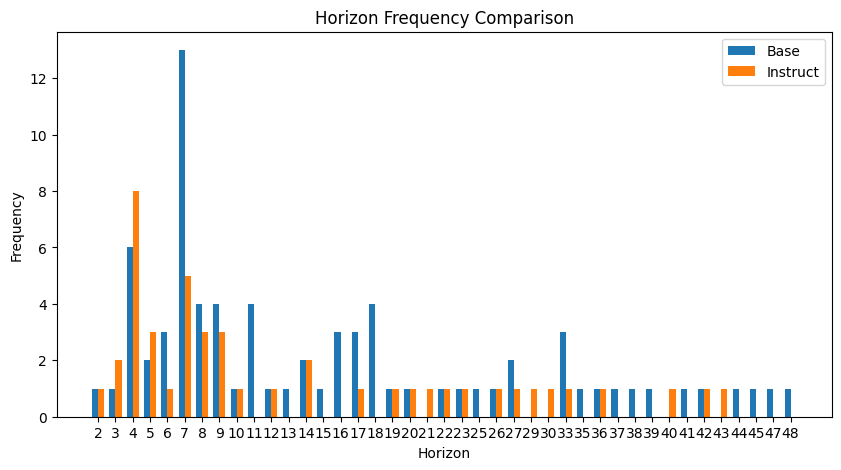

In [35]:
plot_horizon_comparison(planning_dist_base_freq, planning_dist_instruct_freq, "Base", "Instruct")

In [36]:
def plot_horizon_lines(d1, d2, label1="Dict 1", label2="Dict 2"):
    horizons = sorted(set(d1) | set(d2))

    y1 = [d1.get(h, 0) for h in horizons]
    y2 = [d2.get(h, 0) for h in horizons]

    plt.figure(figsize=(10, 5))
    plt.plot(horizons, y1, marker='o', label=label1)
    plt.plot(horizons, y2, marker='o', label=label2)

    plt.xlabel("Horizon")
    plt.ylabel("Frequency")
    plt.title("Horizon Frequency Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


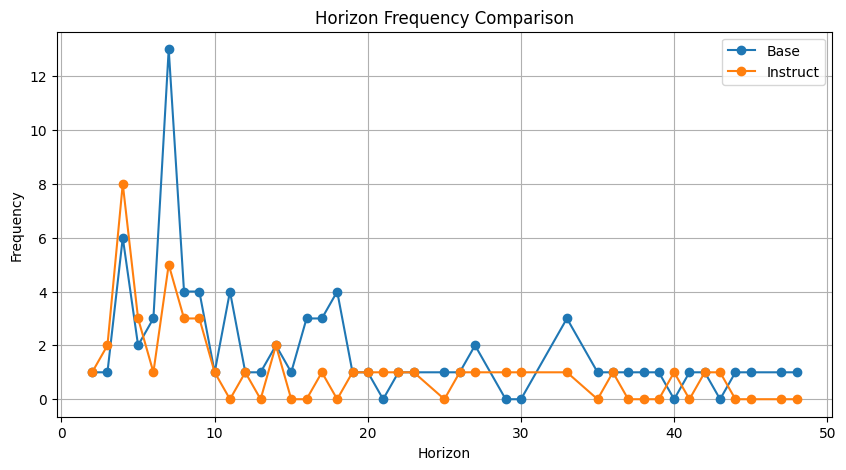

In [37]:
plot_horizon_lines(planning_dist_base_freq, planning_dist_instruct_freq, "Base", "Instruct")